# Tarea 1 DAAML

Daniel Alejandro Gonzalez Miranda | 2022436727

### 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import missingno as msno
import warnings
warnings.filterwarnings("ignore")
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

%matplotlib inline

In [2]:
# importamos los datos
df = pd.read_csv("./data/student_productivity.csv", decimal='.')
# creamos una copia de los datos
data = df.copy()

In [3]:
data.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


Según la información de Data Wrangler, la variable "drug_use" contiene un 73% de datos faltantes, por lo que es mejor eliminarla.

In [4]:
data.drop('drug_use', axis=1, inplace=True)

Verificamos los datos faltantes:

<Axes: >

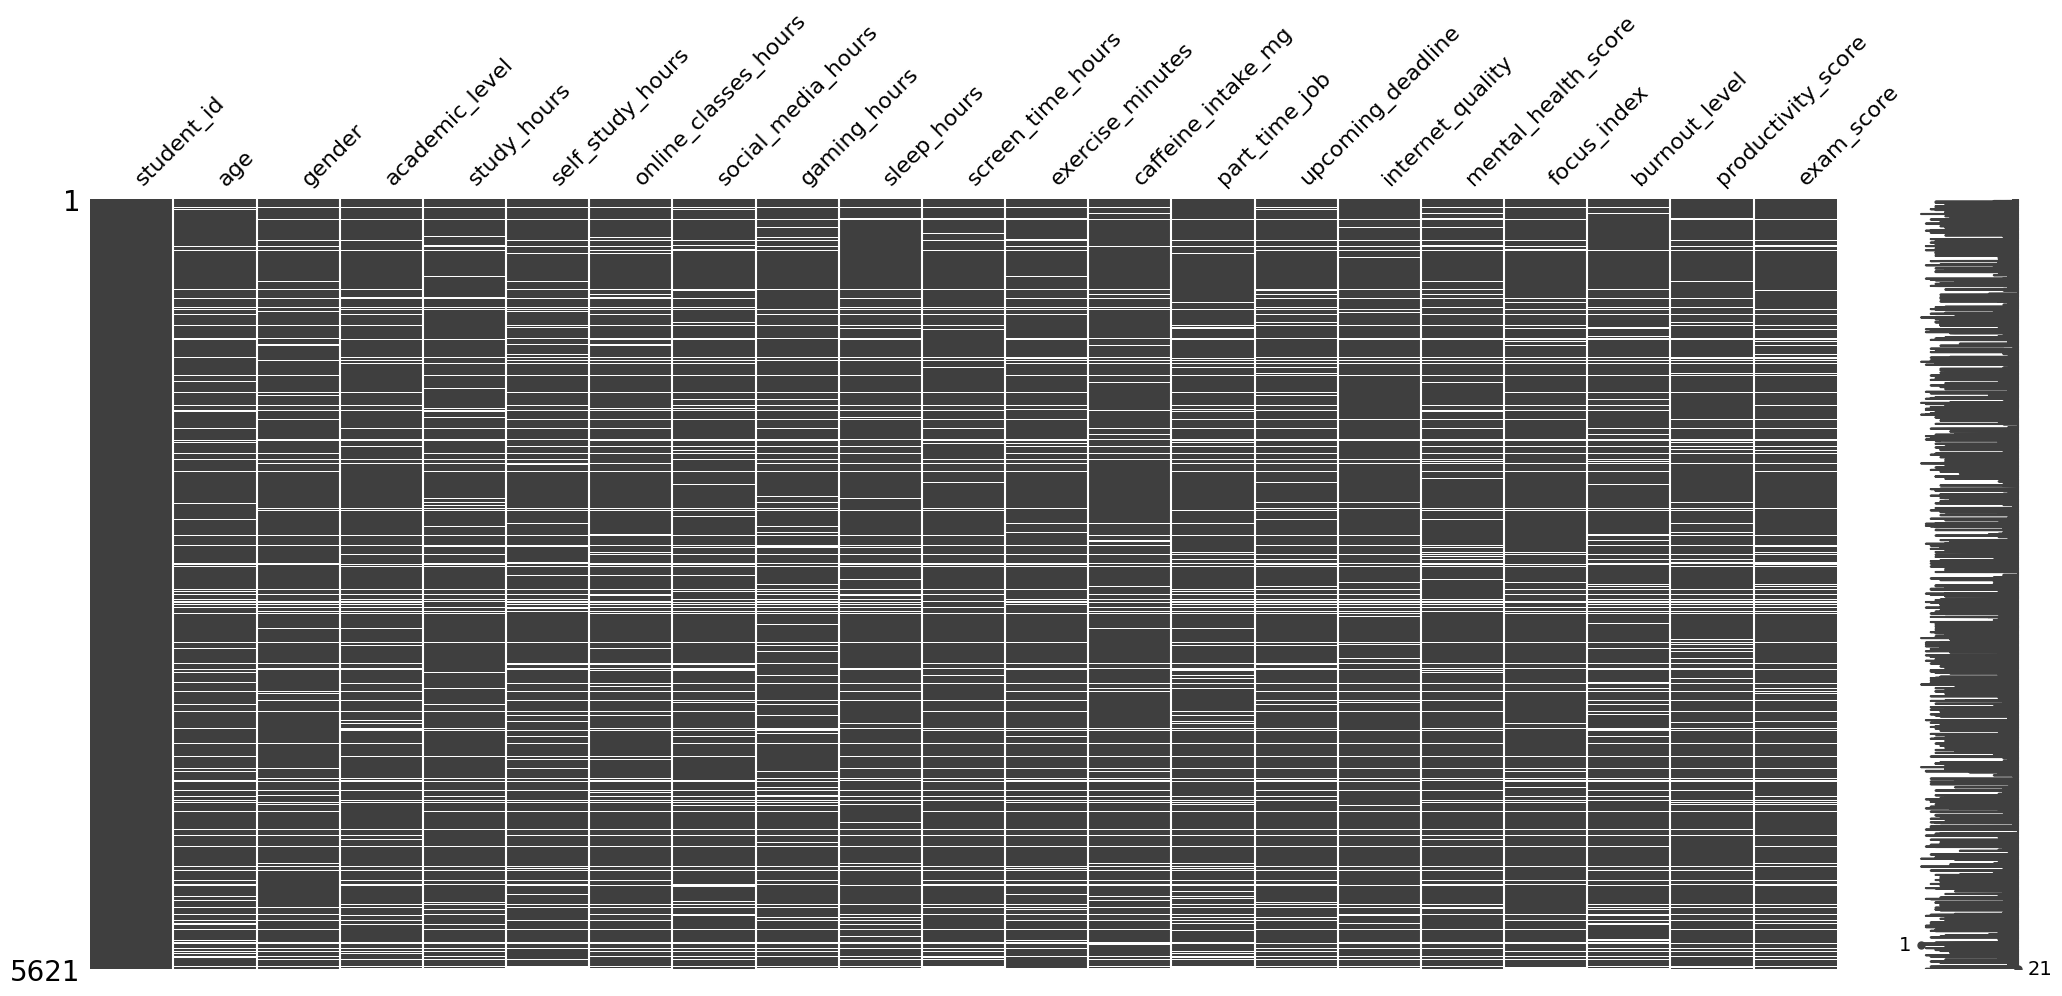

In [5]:
msno.matrix(data)

Se puede apreciar una cantidad significativamente grande de datos faltantes, pero no existen filas vacías, por lo que es necesario hacer un filtro y eliminar filas con cierta cantidad de datos vacíos

<Axes: >

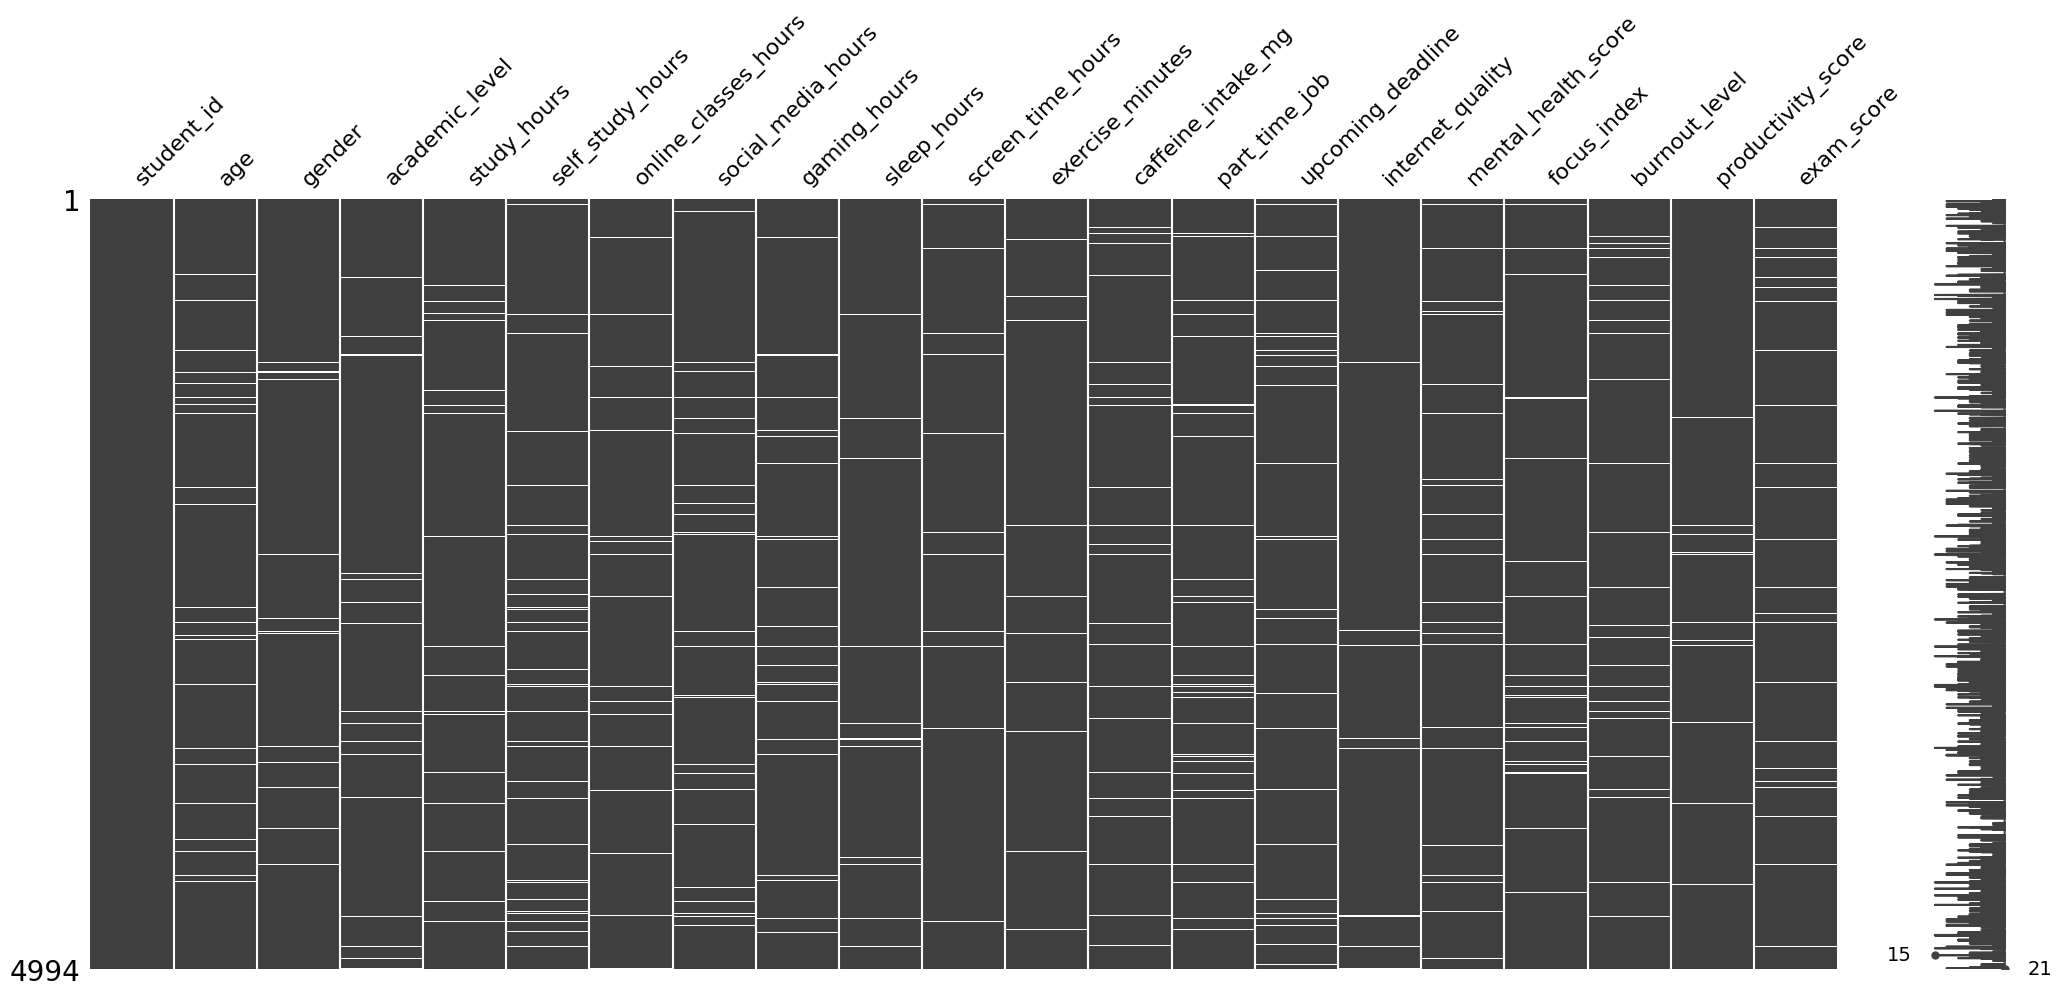

In [6]:
# Eliminamos las filas con más de 5 valores faltantes
data = data.dropna(thresh=data.shape[1] - 6)
msno.matrix(data)

Transformamos datos

In [7]:
# La variable 'exercise_minutes' es del tipo string, por lo que la convertimos a numérica
data['exercise_minutes'] = pd.to_numeric(data['exercise_minutes'], errors='coerce')
# La variable 'part_time_job' tiene datos 'No', 'no', 'Yes' y 'yes' que pueden ser reemplazados por 0 y 1
data['part_time_job'] = data['part_time_job'].replace({'No': 0, 'no': 0, 'Yes': 1, 'yes': 1})  
# La variable 'gender' tiene datos 'Male' y 'Female' que pueden ser reemplazados por 0 y 1 (tambien tiene 'other' pero es un caso muy raro, por lo que lo dejaremos como NA)
data['gender'] = data['gender'].replace({'Male': 0, 'Female': 1})
# Para dejar 'Other' como NA, podemos usar el método replace para convertirlo a NaN
data['gender'] = data['gender'].replace({'Other': np.nan})
data.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,54.0,475.0,0.0,0.0,Good,3.0,19.01,31.77,42.59,25.08
1,2,16.0,1.0,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,63.0,362.0,0.0,0.0,Good,10.0,42.10,45.89,67.15,37.83
2,3,18.0,1.0,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,28.0,200.0,0.0,0.0,Average,5.0,21.93,37.07,37.68,18.66
3,4,24.0,0.0,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,55.0,233.0,0.0,1.0,Poor,3.0,13.47,43.63,12.83,1.00
4,5,24.0,1.0,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,60.0,159.0,0.0,1.0,Poor,2.0,19.95,56.62,18.53,7.78


Hay que completar los datos faltantes con la media, mediana o moda según corresponda.
Tomando en cuenta que, viendo los histogramas, la mayoría de datos distribuyen normal, salvo algunos que tienen ciertas asimetrías, podemos rellenar los datos faltantes de estas variables con la media.

In [8]:
# Completamos los datos faltantes con la media (redondeando a 2 decimales) para las columnas age, study_hours, self_study_hours, online_classes_hours, social_media_hours, sleep_hours, screen_time_hours, exercise_minutes, caffeine_intake_mg, mental_health_score, focus_index, burnout_level, productivity_score
data['age'] = data['age'].fillna(round(data['age'].mean(), 2))
data['study_hours'] = data['study_hours'].fillna(round(data['study_hours'].mean(), 2))
data['self_study_hours'] = data['self_study_hours'].fillna(round(data['self_study_hours'].mean(), 2))
data['online_classes_hours'] = data['online_classes_hours'].fillna(round(data['online_classes_hours'].mean(), 2))
data['social_media_hours'] = data['social_media_hours'].fillna(round(data['social_media_hours'].mean(), 2))
data['sleep_hours'] = data['sleep_hours'].fillna(round(data['sleep_hours'].mean(), 2))
data['screen_time_hours'] = data['screen_time_hours'].fillna(round(data['screen_time_hours'].mean(), 2))
data['exercise_minutes'] = data['exercise_minutes'].fillna(round(data['exercise_minutes'].mean(), 2))
data['caffeine_intake_mg'] = data['caffeine_intake_mg'].fillna(round(data['caffeine_intake_mg'].mean(), 2))
data['mental_health_score'] = data['mental_health_score'].fillna(round(data['mental_health_score'].mean(), 2))
data['focus_index'] = data['focus_index'].fillna(round(data['focus_index'].mean(), 2))
data['burnout_level'] = data['burnout_level'].fillna(round(data['burnout_level'].mean(), 2))
data['productivity_score'] = data['productivity_score'].fillna(round(data['productivity_score'].mean(), 2))

Para las variables binarias, se utiliza la moda

In [9]:
# Para las variables binarias part_time_job, upcoming_deadline y gender, completamos los datos faltantes con la moda
data['part_time_job'] = data['part_time_job'].fillna(data['part_time_job'].mode()[0])
data['upcoming_deadline'] = data['upcoming_deadline'].fillna(data['upcoming_deadline'].mode()[0])
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,0.0,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,54.0,475.0,0.0,0.0,Good,3.0,19.01,31.77,42.59,25.08
1,2,16.0,1.0,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,63.0,362.0,0.0,0.0,Good,10.0,42.10,45.89,67.15,37.83
2,3,18.0,1.0,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,28.0,200.0,0.0,0.0,Average,5.0,21.93,37.07,37.68,18.66
3,4,24.0,0.0,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,55.0,233.0,0.0,1.0,Poor,3.0,13.47,43.63,12.83,1.00
4,5,24.0,1.0,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,60.0,159.0,0.0,1.0,Poor,2.0,19.95,56.62,18.53,7.78


<Axes: >

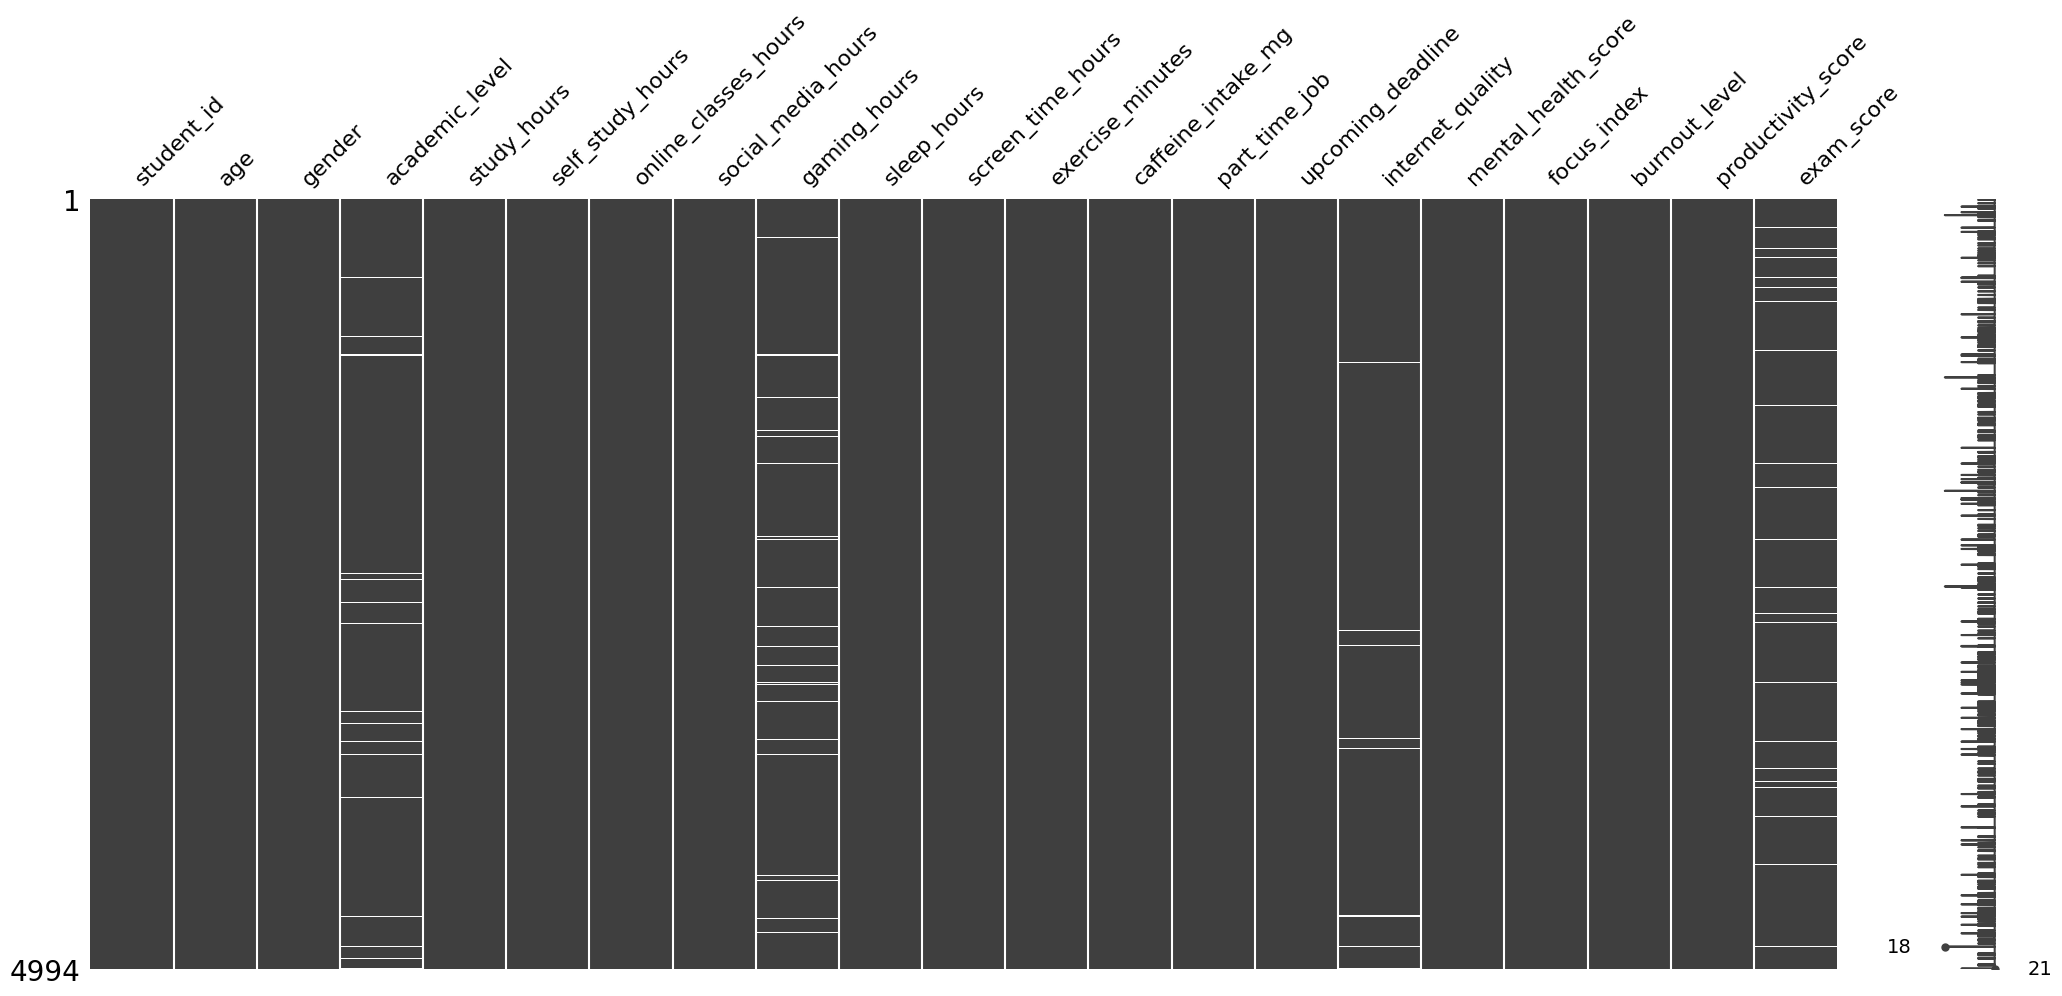

In [10]:
msno.matrix(data)

Creamos una nueva valiable para saber si es que el alumno rindió o no el examen

In [11]:
# Generamos una nueva columna llamada 'rinde' que es 0 cuando 'exam_score' es 1 y 1 cuando 'exam_score' es cualquier otro valor
data['rinde'] = data['exam_score'].apply(lambda x: 0 if x == 1 else 1)
data.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rinde
0,1,20.0,0.0,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,0.0,0.0,Good,3.0,19.01,31.77,42.59,25.08,1
1,2,16.0,1.0,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,0.0,0.0,Good,10.0,42.10,45.89,67.15,37.83,1
2,3,18.0,1.0,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,0.0,0.0,Average,5.0,21.93,37.07,37.68,18.66,1
3,4,24.0,0.0,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,0.0,1.0,Poor,3.0,13.47,43.63,12.83,1.00,0
4,5,24.0,1.0,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,0.0,1.0,Poor,2.0,19.95,56.62,18.53,7.78,1


Finalmente seguimos llenando los datos NaN con respecto a los criterios vistos anteriormente

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rinde
0,1,20.0,0.0,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,0.0,0.0,Good,3.0,19.01,31.77,42.59,25.080000,1
1,2,16.0,1.0,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,0.0,0.0,Good,10.0,42.10,45.89,67.15,37.830000,1
2,3,18.0,1.0,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,0.0,0.0,Average,5.0,21.93,37.07,37.68,18.660000,1
3,4,24.0,0.0,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,0.0,1.0,Poor,3.0,13.47,43.63,12.83,1.000000,0
4,5,24.0,1.0,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,0.0,1.0,Poor,2.0,19.95,56.62,18.53,7.780000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,5613,18.0,0.0,Postgraduate,4.30,2.34,0.70,0.43,4.04,7.39,...,87.0,0.0,1.0,Poor,2.0,36.18,40.42,31.42,10.570000,1
5614,5615,25.0,1.0,NaN,3.85,2.63,2.01,2.55,2.46,8.15,...,453.0,1.0,1.0,NaN,10.0,38.26,57.39,45.30,23.770000,1
5615,5616,17.0,0.0,High School,6.55,2.48,2.01,3.42,2.44,6.17,...,173.0,1.0,1.0,Poor,7.0,34.70,56.14,47.66,20.616782,1
5616,5617,21.0,0.0,Postgraduate,4.16,0.00,1.27,4.01,3.41,8.07,...,152.0,0.0,1.0,Poor,7.0,21.78,48.07,43.06,17.150000,1


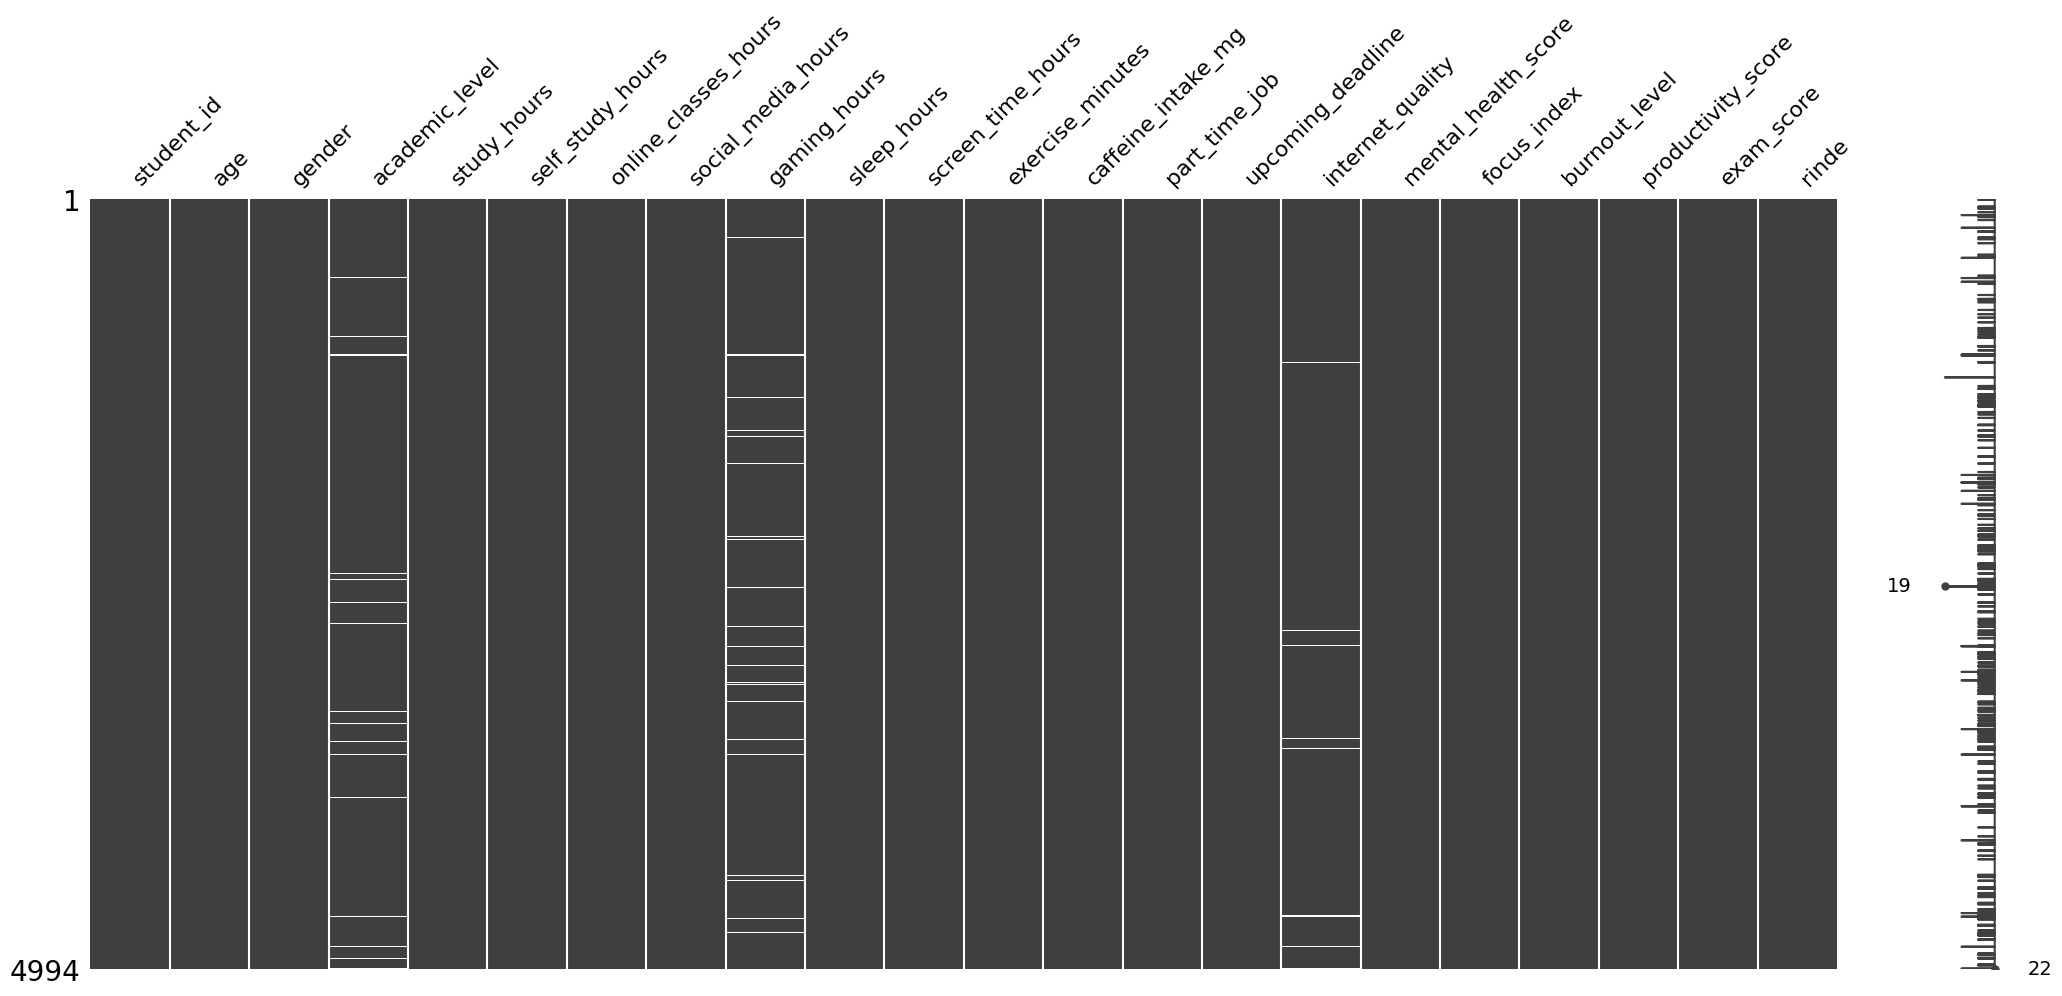

In [12]:
# Ahora, completamos los datos faltantes de 'exam_score' con la media, pero solo para los casos donde 'rinde' es 1 (es decir, donde 'exam_score' no es 1)
data.loc[data['rinde'] == 1, 'exam_score'] = data.loc[data['rinde'] == 1, 'exam_score'].fillna(data.loc[data['rinde'] == 1, 'exam_score'].mean())
msno.matrix(data)
data

<Axes: >

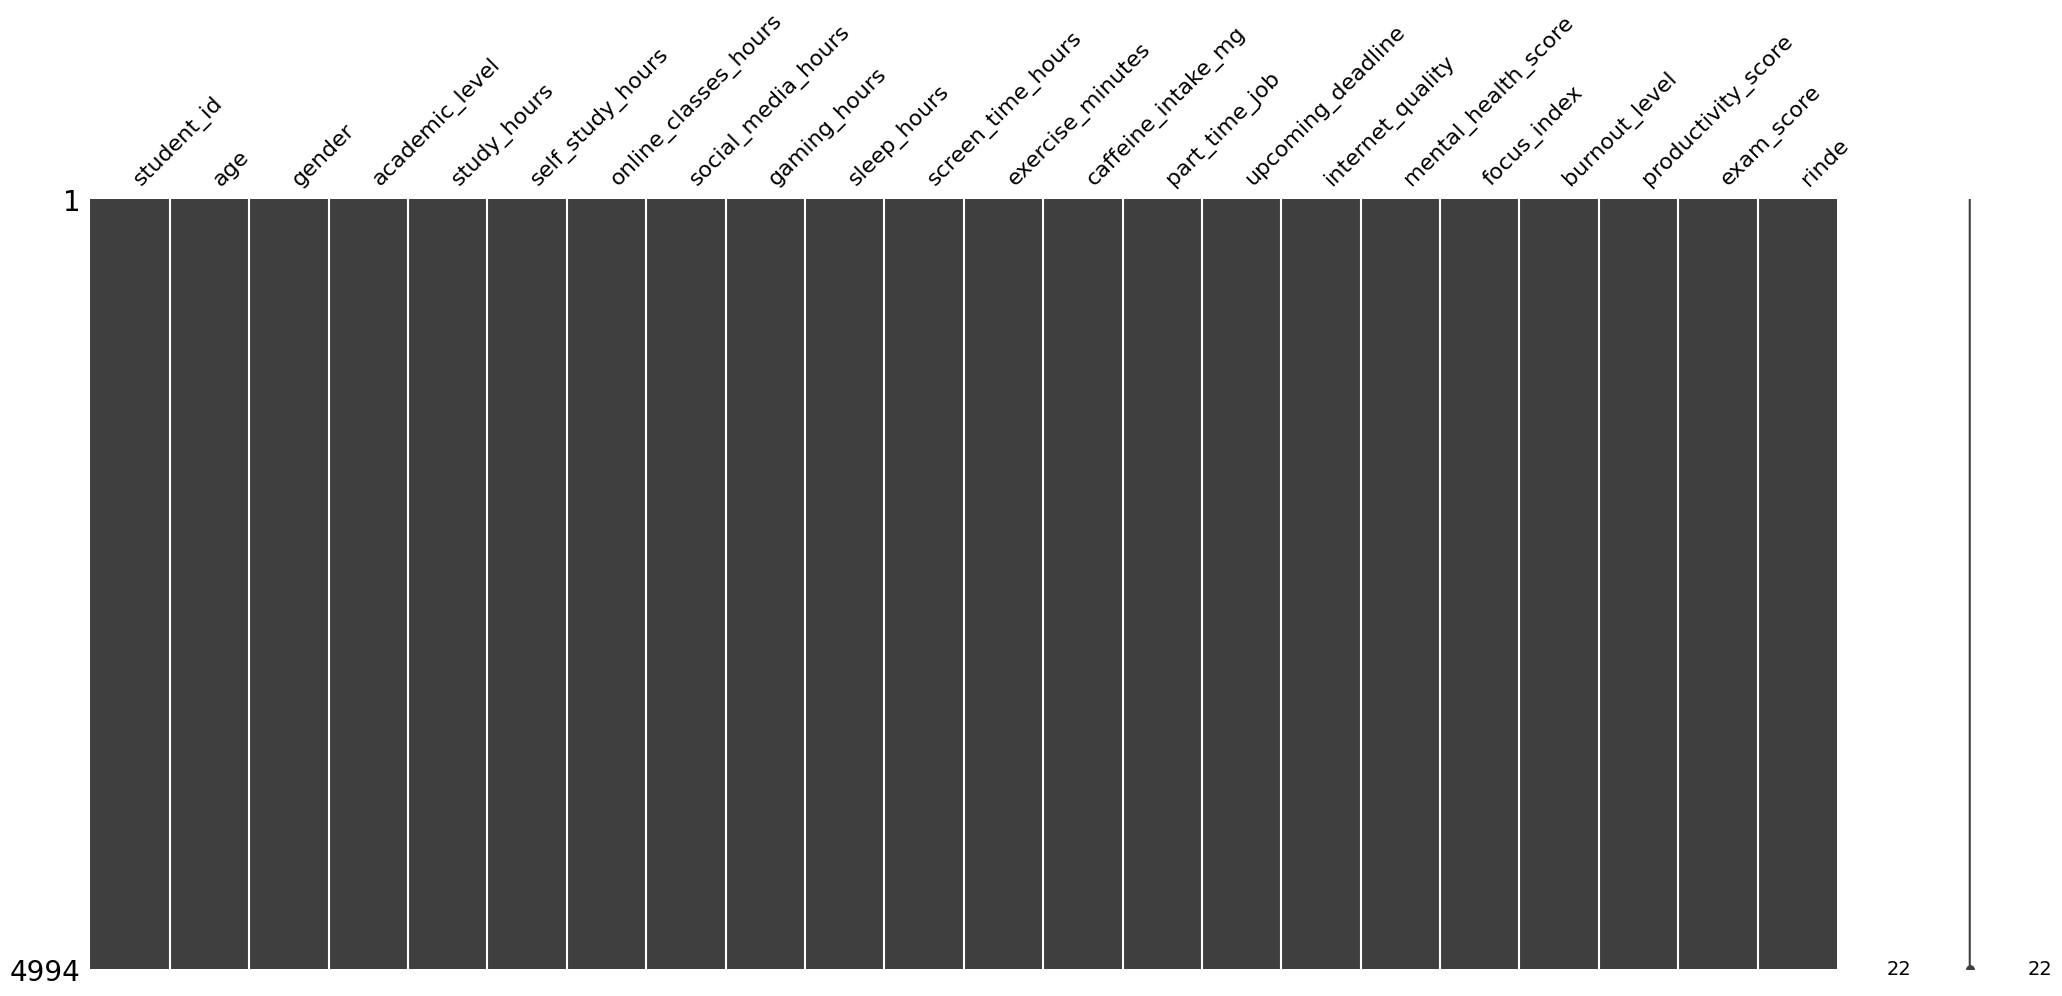

In [13]:
# para 'academic_level' e 'internet_quality', completamos los datos faltantes con la moda
data['academic_level'] = data['academic_level'].fillna(data['academic_level'].mode()[0])
data['internet_quality'] = data['internet_quality'].fillna(data['internet_quality'].mode()[0])
# para gaming_hours, completamos los datos faltantes con la mediana (datos asimetricos )
data['gaming_hours'] = data['gaming_hours'].fillna(data['gaming_hours'].median())
msno.matrix(data)

In [14]:
# Transformamos 'academic_level' e 'internet_quality' a variables numericas categoricas ordinales
data['academic_level'] = data['academic_level'].replace({'High School': 0, 'High School ': 0, 'Undergraduate': 1, 'Undergraduate ': 1, 'Postgraduate': 2, 'Postgraduate ' : 2})
data['internet_quality'] = data['internet_quality'].replace({'Poor': 0, 'Average': 1, 'Good': 2})
data

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rinde
0,1,20.0,0.0,1,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,0.0,0.0,2,3.0,19.01,31.77,42.59,25.080000,1
1,2,16.0,1.0,0,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,0.0,0.0,2,10.0,42.10,45.89,67.15,37.830000,1
2,3,18.0,1.0,1,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,0.0,0.0,1,5.0,21.93,37.07,37.68,18.660000,1
3,4,24.0,0.0,1,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,0.0,1.0,0,3.0,13.47,43.63,12.83,1.000000,0
4,5,24.0,1.0,2,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,0.0,1.0,0,2.0,19.95,56.62,18.53,7.780000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,5613,18.0,0.0,2,4.30,2.34,0.70,0.43,4.04,7.39,...,87.0,0.0,1.0,0,2.0,36.18,40.42,31.42,10.570000,1
5614,5615,25.0,1.0,2,3.85,2.63,2.01,2.55,2.46,8.15,...,453.0,1.0,1.0,2,10.0,38.26,57.39,45.30,23.770000,1
5615,5616,17.0,0.0,0,6.55,2.48,2.01,3.42,2.44,6.17,...,173.0,1.0,1.0,0,7.0,34.70,56.14,47.66,20.616782,1
5616,5617,21.0,0.0,2,4.16,0.00,1.27,4.01,3.41,8.07,...,152.0,0.0,1.0,0,7.0,21.78,48.07,43.06,17.150000,1


In [15]:
# Creamos variables para si una persona hace ejercicio o no (exercise_minutes > 0), si es que juega videojuegos o no (gaming_hours > 0) y si es que usa redes sociales o no (social_media_hours > 0)
data['hace_ejercicio'] = data['exercise_minutes'].apply(lambda x: 1 if x > 0 else 0)
data['juega_videojuegos'] = data['gaming_hours'].apply(lambda x: 1 if x > 0 else 0)
data['usa_redes_sociales'] = data['social_media_hours'].apply(lambda x: 1 if x > 0 else 0)
data

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,rinde,hace_ejercicio,juega_videojuegos,usa_redes_sociales
0,1,20.0,0.0,1,5.37,2.09,1.85,3.66,2.32,7.73,...,2,3.0,19.01,31.77,42.59,25.080000,1,1,1,1
1,2,16.0,1.0,0,5.85,5.04,1.87,3.60,2.79,6.11,...,2,10.0,42.10,45.89,67.15,37.830000,1,1,1,1
2,3,18.0,1.0,1,5.69,2.27,0.00,2.93,3.94,7.11,...,1,5.0,21.93,37.07,37.68,18.660000,1,1,1,1
3,4,24.0,0.0,1,2.32,1.06,2.30,4.34,2.37,8.54,...,0,3.0,13.47,43.63,12.83,1.000000,0,1,1,1
4,5,24.0,1.0,2,3.87,2.63,2.54,3.71,1.30,7.69,...,0,2.0,19.95,56.62,18.53,7.780000,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,5613,18.0,0.0,2,4.30,2.34,0.70,0.43,4.04,7.39,...,0,2.0,36.18,40.42,31.42,10.570000,1,1,1,1
5614,5615,25.0,1.0,2,3.85,2.63,2.01,2.55,2.46,8.15,...,2,10.0,38.26,57.39,45.30,23.770000,1,1,1,1
5615,5616,17.0,0.0,0,6.55,2.48,2.01,3.42,2.44,6.17,...,0,7.0,34.70,56.14,47.66,20.616782,1,1,1,1
5616,5617,21.0,0.0,2,4.16,0.00,1.27,4.01,3.41,8.07,...,0,7.0,21.78,48.07,43.06,17.150000,1,1,1,1


Creamos un mapa de calor con las correlaciones y así ver las variables más importantes para nuestro modelo

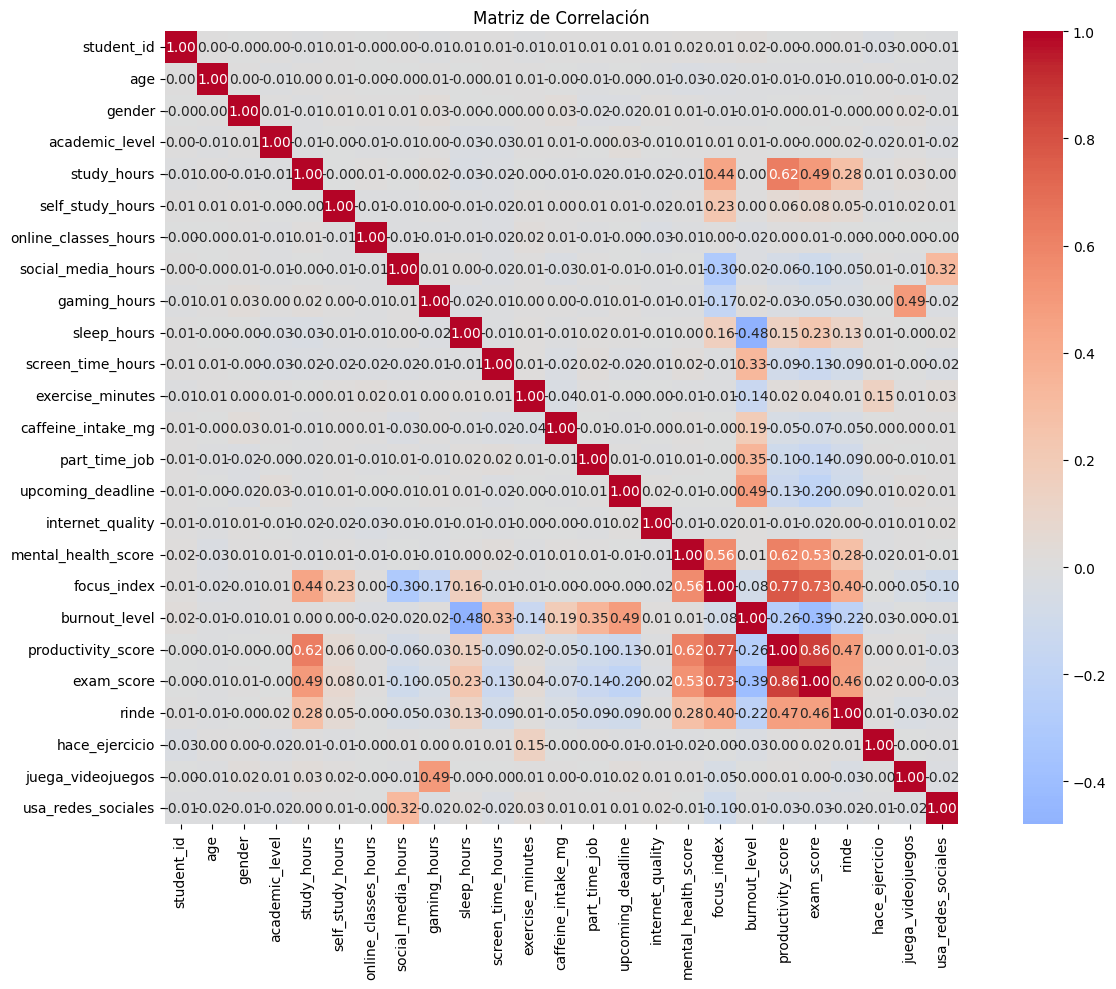

In [16]:
# Crear una matriz de correlación para data
correlation_matrix = data.corr()

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Podemos apreciar correlaciones significativas de la variable 'rinde' con exam_score (por obvias razones), productivity_score, focus_index, mental_health_score y study_hours.
También hay variables con un poco menos de correlación, como sleep_hours y burnout_level (que tiene correlación negativa)

Para el MCO se seleccionaron las variables:
- productivity_score
- focus_index
- mental_health_score
- study_hours
- sleep_hours
- burnout_level

### 2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [17]:
formula = '''rinde ~ productivity_score + focus_index + mental_health_score + study_hours + burnout_level + sleep_hours + burnout_level'''

modelo = smf.ols(formula, data = data).fit(cov_type='HC1')
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  rinde   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     117.9
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.14e-139
Time:                        15:09:57   Log-Likelihood:                -70.143
No. Observations:                4994   AIC:                             154.3
Df Residuals:                    4987   BIC:                             199.9
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7013    

Podemos apreciar que las variables con mayor coeficiente son productivity_score, focus_index, study_hours y burnout_level, siendo esta última la única, junto con sleep_hours, con coeficiente negativo.

mental_health_score, study_hours y sleep_hours resultaron no ser significativas, mientras que el resto si cuentan con un valor P < 0.05.

El R-squared es bastante bajo, por lo que el modelo no explica en su mayoría nuestra variable dependiente.

### 3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [18]:
probit = smf.probit(formula, data=data).fit(cov_type='HC1')
print(probit.summary())

Optimization terminated successfully.
         Current function value: 0.129994
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                  rinde   No. Observations:                 4994
Model:                         Probit   Df Residuals:                     4987
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5591
Time:                        15:09:57   Log-Likelihood:                -649.19
converged:                       True   LL-Null:                       -1472.5
Covariance Type:                  HC1   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.2188      0.390     -0.561      0.575      -0.984       0.546
pr

Los resultados, tanto en coeficientes como en significancia, son similares, aunque con la diferencia que en este caso los coeficientes son considerablemente más altos, burnout_level ahora es la única variable con coeficiente negativo y se puede apreciar que la salud mental aunmentó su significancia, mientras que las horas de estudio disminuyeron la suya.

El pseudo R-squared es mayor en este caso, por lo que si podemos decir que el modelo ya explica lo suficiente nuestra variable (en comparación con el modelo anterior).

### 4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [19]:
logit = smf.logit(formula, data=data).fit()
print(logit.summary())

mfx = logit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.130302
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  rinde   No. Observations:                 4994
Model:                          Logit   Df Residuals:                     4987
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5581
Time:                        15:09:57   Log-Likelihood:                -650.73
converged:                       True   LL-Null:                       -1472.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.5189      0.699     -0.742      0.458      -1.889       0.851
pr

Resultados bien similares al del caso anterior, con coeficientes aún mayores, las horas de estudio ahora afectan negativamente y las significancias también cambiaron de forma similar que en el caso anterior.

### 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [21]:
stargazer = Stargazer([modelo, probit, logit])

# 3. Configuración de la visualización
stargazer.title("Comparación de Modelos: MCO, Probit y Logit")
stargazer.custom_columns(["Modelo MCO", "Modelo Probit", "Modelo Logit"], [1, 1, 1])
stargazer.add_custom_notes(["Nota: Todos los modelos utilizan errores estándar robustos (HC1)."])

# 4. Renderizado para Jupyter Notebook
HTML(stargazer.render_html())

Debido a la naturaleza de los modelos, Probit y Logit son los mejores para este tipo de análisis.

### 6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

Filtramos los datos para considerar solo quienes rindieron el examen

In [ ]:
data_examen = data[data['rinde'] == 1]


Para el modelo agregaré además la variable 'upcoming_deadline', 'part_time_job' y 'screen_time_hours'

In [27]:
formula_ps = '''exam_score ~ productivity_score + focus_index + mental_health_score + study_hours + burnout_level + sleep_hours + burnout_level + upcoming_deadline + part_time_job + screen_time_hours'''
modelo_ps = smf.poisson(formula_ps, data=data_examen).fit(cov_type='HC1')
print(modelo_ps.summary())

Optimization terminated successfully.
         Current function value: 3.290639
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4561
Model:                        Poisson   Df Residuals:                     4551
Method:                           MLE   Df Model:                            9
Date:               mi., 22 abr. 2026   Pseudo R-squ.:                  0.3995
Time:                        15:30:07   Log-Likelihood:                -15009.
converged:                       True   LL-Null:                       -24993.
Covariance Type:                  HC1   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.0175      0.049     41.185      0.000       1.921       2.113
pr

De las tres variables agregadas, solo upcoming_deadline fue significativa, pero las tres afectan negativamente a la nota del examen.


### 7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [28]:
# Se compara media y varianza
media = data_examen['exam_score'].mean()
varianza = data_examen['exam_score'].var()

print(f"Media: {media}")
print(f"Varianza: {varianza}")

Media: 20.61678244972578
Varianza: 122.18590269668688


Como la varianza es muy mayor a la media, podemos suponer que existe una sobre dispersión en los datos

In [31]:
# Test de Overdispersion.
aux=((data_examen['exam_score']-modelo_ps.predict())**2-modelo_ps.predict())/modelo_ps.predict()
auxr=sm.OLS(aux,modelo_ps.predict()).fit()
print(auxr.summary())

                                 OLS Regression Results                                
Dep. Variable:             exam_score   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):              0.035
Method:                 Least Squares   F-statistic:                              165.3
Date:               mi., 22 abr. 2026   Prob (F-statistic):                    3.40e-37
Time:                        15:44:48   Log-Likelihood:                         -11351.
No. Observations:                4561   AIC:                                  2.270e+04
Df Residuals:                    4560   BIC:                                  2.271e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Se realizó un test de sobredispersión, donde se puede concluír que efectivamente existe una sobredispersión. Además podemos obtener el alpha óptimo para un modelo de binomial negativa, siendo este = 0.0242.

### 8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [32]:
# Para calcular alpha:
modelo_nb = smf.negativebinomial(formula_ps, data=data_examen).fit()

print(modelo_nb.summary())

Optimization terminated successfully.
         Current function value: 3.218068
         Iterations: 27
         Function evaluations: 46
         Gradient evaluations: 39
                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 4561
Model:               NegativeBinomial   Df Residuals:                     4551
Method:                           MLE   Df Model:                            9
Date:               mi., 22 abr. 2026   Pseudo R-squ.:                  0.1540
Time:                        15:46:27   Log-Likelihood:                -14678.
converged:                       True   LL-Null:                       -17350.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           

Podemos apreciar que, aunque siguen habiendo variables poco significativas, estas aumentaron su significancia.


### 9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [33]:
stargazer_conteo = Stargazer([modelo_ps, modelo_nb])
stargazer_conteo.title('Comparación de Modelos: Poisson vs Binomial Negativo')
stargazer_conteo.add_custom_notes([
    "Errores estándar robustos HC1 entre paréntesis.",
    'Alpha en BN confirma sobredispersión.'])

HTML(stargazer_conteo.render_html())

Ambos modelos son bastante similares en cuanto a coeficientes y variables robustas.

Variables robustas:
- productivity_score
- focus_index
- mental_health_score
- study_hours
- burnout_level
- upcoming_deadline

Variables no robustas:
- sleep_hours
- part_time_job
- screen_time_hours

La principal diferencia entre ambos modelos radica en que el modelo poisson presenta sobredispersión, la cual es corregida mediante la binomial negativa y por tanto este modelo es el mejor para este caso.